# Cu2O U-Net End-to-End Workflow

This notebook demonstrates the end-to-end workflow for atom segmentation from in-situ HRTEM data:

1. Load an HRTEM image or stack and its IFFT-filtered partner.
2. Generate Cu2O atom labels with blob detection, intensity filtering, and nearest-neighbor filtering.
3. Convert the image and labels into the `(frames, 512, 512, 1)` arrays expected by the U-Net.
4. Train the U-Net on the generated labels.
5. Run inference and compare predictions with the generated labels.

To apply the workflow to another dataset, change the paths and parameters in the next cell. The bundled TIFF files are small files included for demonstration purposes.

## 1. Configure the dataset and workflow

Replace `HRTEM_PATH` and `IFFT_PATH` with aligned TIFF images or TIFF stacks from another experiment. The two inputs must have the same frame count and should already be spatially aligned. For a quick reviewer demonstration, `EPOCHS` is set low; use a larger value such as `300` for a full training run.

In [8]:
from pathlib import Path

# Input data. Replace these two files with your own aligned HRTEM/IFFT pair.
HRTEM_PATH = Path("data_preparation/HRTEM.tiff")
IFFT_PATH = Path("data_preparation/IFFT.tiff")

# Output locations for this notebook run.
WORKFLOW_NAME = "notebook_demo"
LABEL_DIR = Path("outputs") / WORKFLOW_NAME / "labels"
DATASET_DIR = Path("data") / WORKFLOW_NAME
AUGMENTED_DATASET_DIR = Path("data") / f"{WORKFLOW_NAME}_augmented"
TRAIN_DIR = Path("results") / WORKFLOW_NAME / "training"
TRAINED_PRED_DIR = Path("results") / WORKFLOW_NAME / "trained_model_predictions"
PRETRAINED_PRED_DIR = Path("results") / WORKFLOW_NAME / "pretrained_model_predictions"

# Optional centered crop before label generation and array building.
# Leave both as None to use the full frame.
CROP_HEIGHT = None
CROP_WIDTH = None

# Label-generation parameters. Tune these for different contrast, magnification, or lattice spacing.
MIN_INTENSITY = 85
MAX_INTENSITY = 210
NN_MIN = 8.6
NN_MAX = 12.0
SECOND_NN_MAX = 15.0
BLOB_THRESHOLD = 2.5e-5
MASK_RADIUS = 3

# Data augmentation settings. These defaults follow the workflow used for model training.
RUN_AUGMENTATION = True
ROTATION_ANGLES = "0:360:10"      # 36 rotations: 0, 10, ..., 350 degrees.
MAGNIFICATIONS = "90,95,105,110"  # Percent scale factors.
BLUR_SIGMAS = "1,2"               # Gaussian blur sigma values applied to images only.

# Training and inference settings.
EPOCHS = 5          # Use a larger value, e.g. 300, for a full training run.
BATCH_SIZE = 1      # Increase when training on larger datasets and enough GPU memory is available.
GPU_ID = ""         # CPU by default. Set to "0" or "1" to expose a CUDA device.
RUN_TRAINING = True
RUN_PRETRAINED_INFERENCE = True

print(f"HRTEM input: {HRTEM_PATH}")
print(f"IFFT input:  {IFFT_PATH}")
print(f"Label output: {LABEL_DIR}")
print(f"Dataset output: {DATASET_DIR}")
print(f"Augmented dataset output: {AUGMENTED_DATASET_DIR}")

HRTEM input: data_preparation/HRTEM.tiff
IFFT input:  data_preparation/IFFT.tiff
Label output: outputs/notebook_demo/labels
Dataset output: data/notebook_demo
Augmented dataset output: data/notebook_demo_augmented


## 2. Import utilities and preview the input images

The preview makes the input pair visible before any processing.

<tifffile.TiffFile 'HRTEM.tiff'> ImageJ series metadata invalid or corrupted file
<tifffile.TiffFile 'IFFT.tiff'> ImageJ series metadata invalid or corrupted file


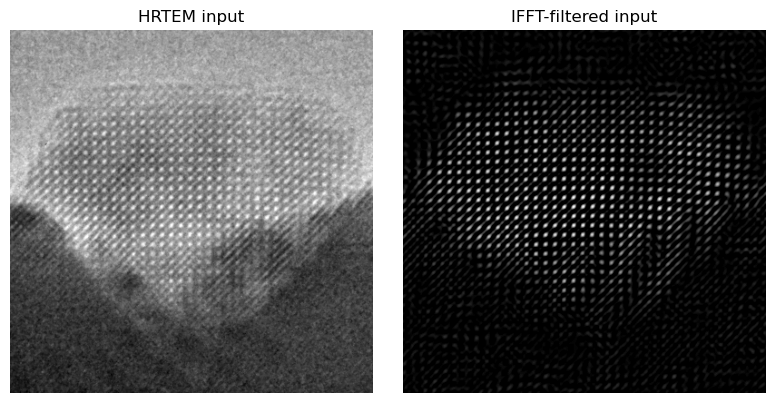

In [9]:
%matplotlib inline

import csv
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import tifffile
from IPython.display import display

PYTHON = sys.executable

def run_command(command):
    command = [str(part) for part in command]
    print("$ " + " ".join(command))
    subprocess.run(command, check=True)

def as_frames(array):
    array = np.asarray(array)
    if array.ndim == 2:
        return array[np.newaxis, ...]
    if array.ndim == 3:
        return array
    if array.ndim == 4 and array.shape[-1] == 1:
        return array[..., 0]
    raise ValueError(f"Expected 2-D, 3-D, or singleton-channel 4-D data; got {array.shape}")

def read_first_frame(path):
    return as_frames(tifffile.imread(path))[0]

def overlay_mask(ax, image, mask, title):
    ax.imshow(image, cmap="gray")
    if np.any(mask):
        ax.contour(mask > 0, levels=[0.5], colors="tab:red", linewidths=0.5)
    ax.set_title(title)
    ax.axis("off")

hrtem_preview = read_first_frame(HRTEM_PATH)
ifft_preview = read_first_frame(IFFT_PATH)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(hrtem_preview, cmap="gray")
axes[0].set_title("HRTEM input")
axes[0].axis("off")
axes[1].imshow(ifft_preview, cmap="gray")
axes[1].set_title("IFFT-filtered input")
axes[1].axis("off")
plt.tight_layout()

## 3. Generate Cu2O atom labels

This step applies determinant-of-Hessian blob detection to the IFFT image, then filters candidates using HRTEM intensity and nearest-neighbor spacing. The command writes a binary mask, a visual overlay, and a CSV table of accepted atom coordinates.

In [10]:
label_command = [
    PYTHON,
    "data_preparation/generate_cu2o_labels.py",
    "--hrtem", HRTEM_PATH,
    "--ifft", IFFT_PATH,
    "--output-dir", LABEL_DIR,
    "--min-intensity", MIN_INTENSITY,
    "--max-intensity", MAX_INTENSITY,
    "--nn-min", NN_MIN,
    "--nn-max", NN_MAX,
    "--second-nn-max", SECOND_NN_MAX,
    "--blob-threshold", BLOB_THRESHOLD,
    "--mask-radius", MASK_RADIUS,
]
if CROP_HEIGHT is not None and CROP_WIDTH is not None:
    label_command += ["--crop-height", CROP_HEIGHT, "--crop-width", CROP_WIDTH]

run_command(label_command)

$ /home/blee2/anaconda3/envs/cu2o-seg/bin/python data_preparation/generate_cu2o_labels.py --hrtem data_preparation/HRTEM.tiff --ifft data_preparation/IFFT.tiff --output-dir outputs/notebook_demo/labels --min-intensity 85 --max-intensity 210 --nn-min 8.6 --nn-max 12.0 --second-nn-max 15.0 --blob-threshold 2.5e-05 --mask-radius 3


<tifffile.TiffFile 'HRTEM.tiff'> ImageJ series metadata invalid or corrupted file
<tifffile.TiffFile 'IFFT.tiff'> ImageJ series metadata invalid or corrupted file


frame 0: kept 597 Cu2O atom candidates
wrote outputs/notebook_demo/labels/cu2o_mask.tiff
wrote outputs/notebook_demo/labels/cu2o_overlay.tiff
wrote outputs/notebook_demo/labels/cu2o_points.csv


## 4. Inspect the generated labels

The mask is the training target. The overlay marks accepted atom positions on the HRTEM image so the label quality can be inspected before training. The automatically generated labels should be inspected before they are used for U-Net training. In our workflow, the blob-detection step provides an initial label mask and atom-coordinate table, but these outputs may include false positives or miss atoms in regions with low contrast, overlapping
columns, or heterogeneous background intensity.

Accepted Cu2O atom candidates: 597


[{'frame': '0',
  'y': '183.0',
  'x': '197.0',
  'radius_px': '3.2',
  'intensity': '147.0612244897959',
  'nearest_px': '10.0',
  'second_nearest_px': '10.0'},
 {'frame': '0',
  'y': '193.0',
  'x': '197.0',
  'radius_px': '3.2',
  'intensity': '149.12244897959184',
  'nearest_px': '10.0',
  'second_nearest_px': '10.0'},
 {'frame': '0',
  'y': '183.0',
  'x': '218.0',
  'radius_px': '3.2',
  'intensity': '148.40816326530611',
  'nearest_px': '10.0',
  'second_nearest_px': '10.0'},
 {'frame': '0',
  'y': '172.0',
  'x': '218.0',
  'radius_px': '3.2',
  'intensity': '147.59183673469389',
  'nearest_px': '10.0',
  'second_nearest_px': '11.0'},
 {'frame': '0',
  'y': '195.0',
  'x': '281.0',
  'radius_px': '3.2',
  'intensity': '164.71428571428572',
  'nearest_px': '10.0',
  'second_nearest_px': '10.0'},
 {'frame': '0',
  'y': '193.0',
  'x': '187.0',
  'radius_px': '3.2',
  'intensity': '146.73469387755102',
  'nearest_px': '10.0',
  'second_nearest_px': '10.0'},
 {'frame': '0',
  'y': 

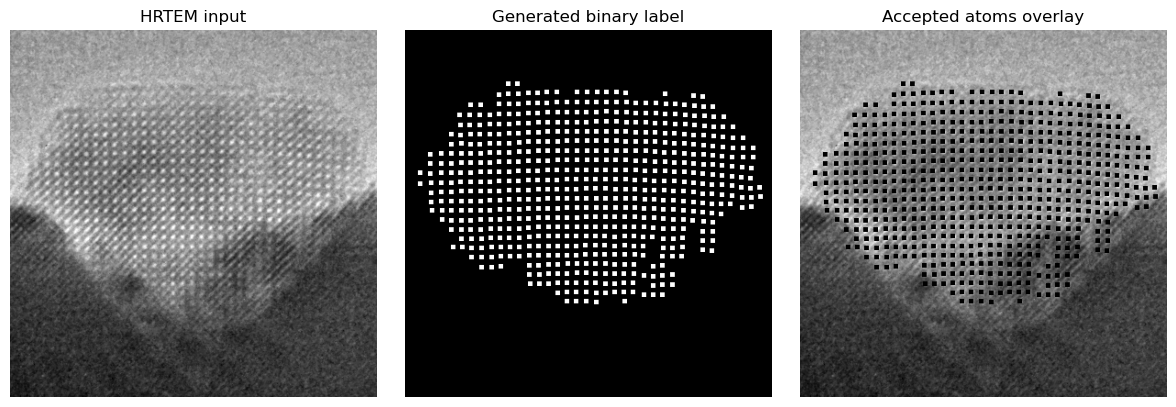

In [11]:
mask_preview = read_first_frame(LABEL_DIR / "cu2o_mask.tiff")
overlay_preview = read_first_frame(LABEL_DIR / "cu2o_overlay.tiff")

with (LABEL_DIR / "cu2o_points.csv").open() as handle:
    points = list(csv.DictReader(handle))

print(f"Accepted Cu2O atom candidates: {len(points)}")
display(points[:8])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(hrtem_preview, cmap="gray")
axes[0].set_title("HRTEM input")
axes[0].axis("off")
axes[1].imshow(mask_preview, cmap="gray")
axes[1].set_title("Generated binary label")
axes[1].axis("off")
axes[2].imshow(overlay_preview, cmap="gray")
axes[2].set_title("Accepted atoms overlay")
axes[2].axis("off")
plt.tight_layout()

## 5. Build U-Net training arrays

The U-Net expects NumPy arrays with shape `(frames, NX, NY, 1)`. Smaller frames are centered and padded; larger frames are center-cropped unless a crop was provided above.

In [12]:
dataset_command = [
    PYTHON,
    "data_preparation/build_unet_dataset.py",
    "--images", HRTEM_PATH,
    "--labels", LABEL_DIR / "cu2o_mask.tiff",
    "--output-dir", DATASET_DIR,
]
if CROP_HEIGHT is not None and CROP_WIDTH is not None:
    dataset_command += ["--crop-height", CROP_HEIGHT, "--crop-width", CROP_WIDTH]

run_command(dataset_command)

data_tem = np.load(DATASET_DIR / "data_tem.npy")
label_tem = np.load(DATASET_DIR / "label.npy")
print("data_tem.npy", data_tem.shape, data_tem.dtype, "min/max", float(data_tem.min()), float(data_tem.max()))
print("label.npy", label_tem.shape, label_tem.dtype, "min/max", float(label_tem.min()), float(label_tem.max()))

$ /home/blee2/anaconda3/envs/cu2o-seg/bin/python data_preparation/build_unet_dataset.py --images data_preparation/HRTEM.tiff --labels outputs/notebook_demo/labels/cu2o_mask.tiff --output-dir data/notebook_demo
wrote data/notebook_demo/data_tem.npy with shape (1, 512, 512, 1)
wrote data/notebook_demo/label.npy with shape (1, 512, 512, 1)
data_tem.npy (1, 512, 512, 1) float32 min/max 29.0 255.0
label.npy (1, 512, 512, 1) float32 min/max 0.0 1.0


<tifffile.TiffFile 'HRTEM.tiff'> ImageJ series metadata invalid or corrupted file


## 6. Confirm the model-ready training pair

This display verifies that the image and label remain aligned after padding or cropping to the U-Net input size.

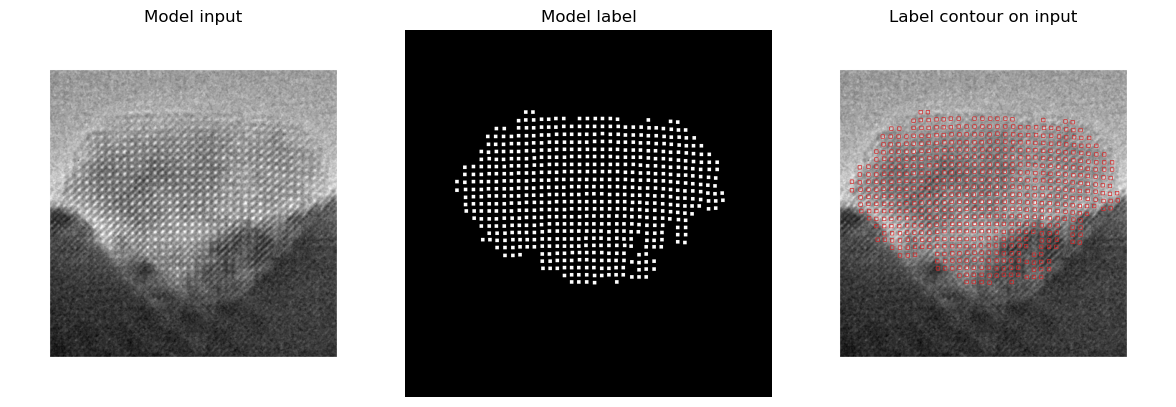

In [13]:
frame_index = 0
image_frame = data_tem[frame_index, ..., 0]
label_frame = label_tem[frame_index, ..., 0]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image_frame, cmap="gray")
axes[0].set_title("Model input")
axes[0].axis("off")
axes[1].imshow(label_frame, cmap="gray")
axes[1].set_title("Model label")
axes[1].axis("off")
overlay_mask(axes[2], image_frame, label_frame, "Label contour on input")
plt.tight_layout()

## 7. Augment the training data

After label inspection and manual correction, the curated image/label arrays are augmented before training. The default augmentation set rotates each image and label every 10 degrees, creates magnification variants at 90%, 95%, 105%, and 110%, and adds Gaussian blur variants to the images. Geometric transforms are applied to the image and label together; label masks use nearest-neighbor interpolation so they remain binary.


$ /home/blee2/anaconda3/envs/cu2o-seg/bin/python data_preparation/dataaugmentation.py --data-dir data/notebook_demo --output-dir data/notebook_demo_augmented --rotation-angles 0:360:10 --magnifications 90,95,105,110 --blur-sigmas 1,2
frame 0: added 36 rotations, 4 magnifications, and 2 blur variants
wrote data/notebook_demo_augmented/data_tem.npy with shape (42, 512, 512, 1)
wrote data/notebook_demo_augmented/label.npy with shape (42, 512, 512, 1)
Training data directory: data/notebook_demo_augmented
augmented data_tem.npy (42, 512, 512, 1) float32
augmented label.npy (42, 512, 512, 1) float32


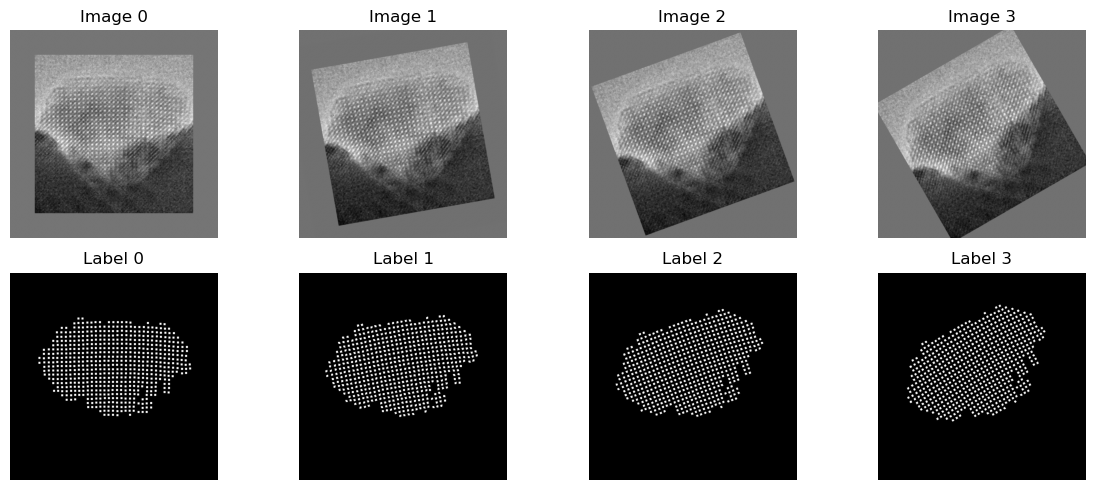

In [14]:
if RUN_AUGMENTATION:
    augment_command = [
        PYTHON,
        "data_preparation/dataaugmentation.py",
        "--data-dir", DATASET_DIR,
        "--output-dir", AUGMENTED_DATASET_DIR,
        "--rotation-angles", ROTATION_ANGLES,
        "--magnifications", MAGNIFICATIONS,
        "--blur-sigmas", BLUR_SIGMAS,
    ]
    run_command(augment_command)
    TRAINING_DATA_DIR = AUGMENTED_DATASET_DIR
else:
    print("Data augmentation skipped. Training will use the non-augmented arrays.")
    TRAINING_DATA_DIR = DATASET_DIR

aug_data_tem = np.load(TRAINING_DATA_DIR / "data_tem.npy")
aug_label_tem = np.load(TRAINING_DATA_DIR / "label.npy")
print("Training data directory:", TRAINING_DATA_DIR)
print("augmented data_tem.npy", aug_data_tem.shape, aug_data_tem.dtype)
print("augmented label.npy", aug_label_tem.shape, aug_label_tem.dtype)

n_preview = min(4, len(aug_data_tem))
fig, axes = plt.subplots(2, n_preview, figsize=(12, 5))
if n_preview == 1:
    axes = np.asarray(axes).reshape(2, 1)
for i in range(n_preview):
    axes[0, i].imshow(aug_data_tem[i, ..., 0], cmap="gray")
    axes[0, i].set_title(f"Image {i}")
    axes[0, i].axis("off")
    axes[1, i].imshow(aug_label_tem[i, ..., 0], cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Label {i}")
    axes[1, i].axis("off")
plt.tight_layout()


## 8. Train the U-Net on the augmented labels

The notebook trains a fresh U-Net using the augmented arrays created above. The default epoch count is intentionally short so the workflow can be reviewed quickly. For a production training run, increase `EPOCHS` in the configuration cell.

In [ ]:
trained_model_path = TRAIN_DIR / "model_final.hdf5"

if RUN_TRAINING:
    train_command = [
        PYTHON,
        "train_unet.py",
        "--data-dir", TRAINING_DATA_DIR,
        "--output-dir", TRAIN_DIR,
        "--epochs", EPOCHS,
        "--batch-size", BATCH_SIZE,
        "--gpu", GPU_ID,
    ]
    run_command(train_command)
else:
    print("Training skipped. The notebook will use the existing trained model path.")

assert trained_model_path.exists(), f"Missing trained model: {trained_model_path}"

## 9. Run inference with the newly trained U-Net

The prediction script writes probability arrays, thresholded masks, and a TIFF mask stack.

In [ ]:
run_command([
    PYTHON,
    "predict.py",
    "--model", trained_model_path,
    "--input", DATASET_DIR / "data_tem.npy",
    "--output-dir", TRAINED_PRED_DIR,
    "--gpu", GPU_ID,
])

trained_probability = np.load(TRAINED_PRED_DIR / "prediction_probability.npy")
trained_mask = np.load(TRAINED_PRED_DIR / "prediction_mask.npy")
print("prediction_probability.npy", trained_probability.shape, trained_probability.dtype)
print("prediction_mask.npy", trained_mask.shape, trained_mask.dtype)

## 10. Visualize inference results

The probability map shows the U-Net output before thresholding. The final panel overlays the predicted mask on the original input frame.

In [ ]:
probability_frame = trained_probability[frame_index, ..., 0]
prediction_frame = trained_mask[frame_index, ..., 0]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(image_frame, cmap="gray")
axes[0].set_title("Input")
axes[0].axis("off")
axes[1].imshow(label_frame, cmap="gray")
axes[1].set_title("Generated label")
axes[1].axis("off")
im = axes[2].imshow(probability_frame, cmap="magma", vmin=0, vmax=1)
axes[2].set_title("U-Net probability")
axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
overlay_mask(axes[3], image_frame, prediction_frame, "Predicted mask contour")
plt.tight_layout()

## 11. Evaluate predictions against generated labels

Evaluation is based on connected-component centroids. Predicted and labeled atoms are matched within a configurable radius, producing true-positive, false-positive, and false-negative counts per frame.

In [ ]:
metrics_path = TRAINED_PRED_DIR / "metrics.csv"
run_command([
    PYTHON,
    "analysis/evaluate_predictions.py",
    "--labels", DATASET_DIR / "label.npy",
    "--predictions", TRAINED_PRED_DIR / "prediction_mask.npy",
    "--output", metrics_path,
])

with metrics_path.open() as handle:
    metrics_rows = list(csv.DictReader(handle))
display(metrics_rows)

## Applying this notebook to another dataset

For a new experiment, change `HRTEM_PATH` and `IFFT_PATH` in the first code cell. If the field of view contains regions outside the interface, set `CROP_HEIGHT` and `CROP_WIDTH` to focus on the centered region. Then inspect the generated overlay before training; if accepted atom positions are missing or incorrect, tune `MIN_INTENSITY`, `MAX_INTENSITY`, `NN_MIN`, `NN_MAX`, `SECOND_NN_MAX`, and `BLOB_THRESHOLD`.